# Walk-Forward Validation — `merton_mom`

**Objective**: Validate whether `MertonMomentumStrategy` with fixed parameters produces robust out-of-sample (OOS) performance across rolling temporal windows.

**Approach**:
1. **Rolling Backtest** — Fixed params, strategy re-initialized per window (train=504d, test=126d)
2. **Sensitivity Analysis** — Small grid around base params to test fragility
3. **Walk-Forward Optimization** — Optimize on train, validate on test, check OOS/IS ratio
4. **Comparison** — Full backtest vs Rolling OOS vs Buy & Hold

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ── Plot style ──
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
})

# Color palette
COLORS = {
    'primary': '#2563eb',
    'secondary': '#7c3aed',
    'success': '#16a34a',
    'danger': '#dc2626',
    'warning': '#f59e0b',
    'info': '#06b6d4',
    'muted': '#9ca3af',
    'dark': '#1f2937',
}
WINDOW_COLORS = ['#2563eb', '#7c3aed', '#059669', '#d97706', '#dc2626',
                 '#0891b2', '#c026d3', '#4f46e5', '#65a30d', '#be123c',
                 '#0d9488', '#a16207']

## 1. Load Universe & Data

In [2]:
from src.io import IO, YFinanceProvider
from src.domain.asset import PriceHistory
from src.domain.portfolio import Portfolio
from src.domain import Broker

universe = IO().load_universe("jaime")
prices = YFinanceProvider().get_prices(universe.tickers, start="2010-01-01", end="2025-12-01")
history = PriceHistory(universe, prices)

print(f"Universe: {len(universe)} assets")
print(f"Period:   {history.dates[0].date()} → {history.dates[-1].date()} ({len(history)} days)")


[                       0%                       ]


[*****                 10%                       ]  2 of 21 completed


[*****                 10%                       ]  2 of 21 completed


[*********             19%                       ]  4 of 21 completed


[************          24%                       ]  5 of 21 completed

...

XLK: 109 missing days (2.7%)


XLP: 109 missing days (2.7%)


XLU: 109 missing days (2.7%)


XLV: 109 missing days (2.7%)


Universe: 21 assets
Period:   2018-04-26 → 2025-11-28 (1854 days)


## 2. Strategy Configuration

In [3]:
from src.strategy.merton_mom import MertonMomentumStrategy
from src.strategy.buy_and_hold import BuyAndHoldStrategy
from src.models.estimators import JamesSteinMean, LedoitWolfCovariance

BASE_PARAMS = dict(
    defensive_ticker="XEON.DE",
    gamma=0.3,
    mu_estimator=JamesSteinMean(),
    cov_estimator=LedoitWolfCovariance(),
    momentum_lookback=252,
    momentum_skip=21,
    momentum_alpha_min=0.3,
    use_dn_bands=True,
    band_scale=2.0,
    max_risky_fraction=1.0,
    rebalance_every=21,
)

INITIAL_CASH = 10_000_000
TRAIN_SIZE = 504   # 2 years
TEST_SIZE = 126    # 6 months

def make_portfolio():
    return Portfolio(initial_cash=INITIAL_CASH, max_leverage=2.0, allow_short=False)

def make_merton_mom(name="merton_mom", **overrides):
    params = {**BASE_PARAMS, **overrides}
    return MertonMomentumStrategy(universe=universe, name=name, **params)

print("Base merton_mom params:")
for k, v in BASE_PARAMS.items():
    if not hasattr(v, '__call__'):
        print(f"  {k}: {v}")

Base merton_mom params:
  defensive_ticker: XEON.DE
  gamma: 0.3
  mu_estimator: JamesSteinMean(trading_days=252, min_periods=20)
  cov_estimator: LedoitWolfCovariance(trading_days=252, min_periods=20)
  momentum_lookback: 252
  momentum_skip: 21
  momentum_alpha_min: 0.3
  use_dn_bands: True
  band_scale: 2.0
  max_risky_fraction: 1.0
  rebalance_every: 21


## 3. Full Backtest (Baseline)

In [4]:
from src.backtesting import Backtest

merton_mom = make_merton_mom()
bnh = BuyAndHoldStrategy(universe=universe, exclude="XEON.DE")

full_result = Backtest(
    portfolio=make_portfolio(),
    universe=universe,
    strategies=[merton_mom, bnh],
    history=history,
    broker=Broker(universe.transaction_costs),
    warmup_size=504,
).run()

print("=" * 60)
print("FULL BACKTEST (in-sample)")
print("=" * 60)
full_result.result("merton_mom").print_summary()

FULL BACKTEST (in-sample)
Period:                2020-05-26 -> 2025-11-28 (1350 days)
Initial value:         $10,000,000.00 (cash=$10,000,000.00)
Final value:           $34,566,845.97
Total return:          245.67%
Annualized return:     26.05%
Annualized vol:        20.08%
Sharpe ratio:          1.2973
Max drawdown:          -27.58%
Calmar ratio:          0.9447
Total costs:           $78,430.01
Signals:               1157
Orders:                1157 (accepted=863, rejected=0, invalid=294)
Trades:                863


## 4. Rolling Walk-Forward (Fixed Params)

Strategy re-initialized every window with 504d warmup, tested on 126d OOS. Portfolio carries over.

In [5]:
from src.backtesting import RollingBacktest

rolling_mom = make_merton_mom(name="merton_mom_rolling")
rolling_bnh = BuyAndHoldStrategy(universe=universe, exclude="XEON.DE", name="bnh_rolling")

rolling_result = RollingBacktest(
    portfolio=make_portfolio(),
    universe=universe,
    strategies=[rolling_mom, rolling_bnh],
    history=history,
    broker=Broker(universe.transaction_costs),
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    step_size=TEST_SIZE,  # non-overlapping
).run()

rolling_strat = rolling_result.result("merton_mom_rolling")
print(f"Windows: {rolling_strat.n_windows}")
print()
print("=" * 60)
print("ROLLING OOS COMBINED")
print("=" * 60)
rolling_strat.print_summary()

Windows: 10

ROLLING OOS COMBINED
Period:                2020-10-05 -> 2025-11-28 (1260 days)
Initial value:         $10,000,000.00 (cash=$10,000,000.00)
Final value:           $24,814,747.64
Total return:          148.15%
Annualized return:     19.93%
Annualized vol:        21.28%
Sharpe ratio:          0.9370
Max drawdown:          -32.55%
Calmar ratio:          0.6124
Total costs:           $90,378.79
Signals:               1236
Orders:                1236 (accepted=849, rejected=0, invalid=387)
Trades:                849


## 5. Per-Window Metrics

In [6]:
# Build per-window metrics table
window_records = []
for i, w in enumerate(rolling_strat.windows):
    m = w.metrics
    window_records.append({
        'Window': i,
        'Start': w.dates[0].strftime('%Y-%m-%d'),
        'End': w.dates[-1].strftime('%Y-%m-%d'),
        'Days': len(w.dates),
        'Return': m['total_return'],
        'Ann. Return': m['annualized_return'],
        'Ann. Vol': m['annualized_volatility'],
        'Sharpe': m['sharpe_ratio'],
        'Max DD': m['max_drawdown'],
        'Calmar': m['calmar_ratio'],
        'Trades': w.total_trades,
        'Costs': w.total_costs,
    })

windows_df = pd.DataFrame(window_records)

# Summary row
full_m = full_result.result("merton_mom").metrics
rolling_m = rolling_strat.metrics

comparison = pd.DataFrame({
    'Full Backtest (IS)': full_m,
    'Rolling Combined (OOS)': rolling_m,
}).T

print("\n" + "=" * 80)
print("PER-WINDOW METRICS")
print("=" * 80)
display(windows_df.style.format({
    'Return': '{:.2%}', 'Ann. Return': '{:.2%}', 'Ann. Vol': '{:.2%}',
    'Sharpe': '{:.3f}', 'Max DD': '{:.2%}', 'Calmar': '{:.3f}',
    'Costs': '${:,.0f}',
}).background_gradient(subset=['Sharpe'], cmap='RdYlGn', vmin=-1, vmax=3)
 .background_gradient(subset=['Max DD'], cmap='RdYlGn', vmin=-0.5, vmax=0))


PER-WINDOW METRICS


,Window,Start,End,Days,Return,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Trades,Costs
0,0,2020-10-05,2021-04-12,126,15.04%,32.35%,18.82%,1.719,-11.89%,2.721,96,"$11,890"
1,1,2021-04-13,2021-10-13,126,8.36%,17.42%,13.82%,1.261,-5.66%,3.079,85,"$4,545"
2,2,2021-10-14,2022-04-21,126,-2.26%,-4.47%,19.56%,-0.229,-14.74%,-0.303,82,"$9,150"
3,3,2022-04-22,2022-10-27,126,-18.19%,-33.08%,29.87%,-1.107,-23.05%,-1.435,124,"$9,324"
4,4,2022-10-28,2023-05-04,126,0.09%,0.19%,15.42%,0.012,-9.20%,0.020,88,"$10,283"
5,5,2023-05-05,2023-11-06,126,5.37%,11.03%,17.46%,0.632,-14.33%,0.770,82,"$6,360"
6,6,2023-11-07,2024-05-14,126,41.84%,101.18%,20.96%,4.828,-7.50%,13.488,70,"$6,606"
7,7,2024-05-15,2024-11-13,126,14.33%,30.71%,26.58%,1.155,-14.56%,2.109,72,"$9,207"
8,8,2024-11-14,2025-05-28,126,12.86%,27.37%,26.91%,1.017,-20.15%,1.358,75,"$11,649"
9,9,2025-05-29,2025-11-28,126,25.07%,56.43%,16.19%,3.484,-7.97%,7.080,75,"$11,367"


In [7]:
# IS vs OOS comparison
oos_sharpe = rolling_m['sharpe_ratio']
is_sharpe = full_m['sharpe_ratio']
oos_is_ratio = oos_sharpe / is_sharpe if is_sharpe != 0 else None

print("\n" + "=" * 60)
print("IS vs OOS COMPARISON")
print("=" * 60)
display(comparison[['total_return', 'annualized_return', 'annualized_volatility',
                     'sharpe_ratio', 'max_drawdown', 'calmar_ratio']].style.format({
    'total_return': '{:.2%}', 'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.4f}',
    'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.4f}',
}))

print(f"\nOOS/IS Sharpe Ratio: {oos_is_ratio:.4f}")
if oos_is_ratio >= 0.6:
    print("✓ ROBUST (>= 0.6)")
elif oos_is_ratio >= 0.3:
    print("⚠ MODERATE (0.3 - 0.6) — some overfitting")
else:
    print("✗ WEAK (< 0.3) — significant overfitting")


IS vs OOS COMPARISON


,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,calmar_ratio
Full Backtest (IS),245.67%,26.05%,20.08%,1.2973,-27.58%,0.9447
Rolling Combined (OOS),148.15%,19.93%,21.28%,0.9370,-32.55%,0.6124



OOS/IS Sharpe Ratio: 0.7222
✓ ROBUST (>= 0.6)


## 6. Walk-Forward Optimization (Sensitivity Grid)

Test whether the base params are near-optimal or if small perturbations dominate.

In [8]:
from src.backtesting import WalkForwardOptimizer, ParameterGrid

# Sensitivity grid: perturbations around base params
sensitivity_grid = ParameterGrid({
    'gamma': [0.2, 0.3, 0.5, 0.8],
    'band_scale': [1.0, 2.0, 3.0],
    'rebalance_every': [10, 21, 42],
    'max_risky_fraction': [0.7, 0.8, 1.0],
})

print(f"Grid size: {len(sensitivity_grid)} combinations")
print(f"Windows: train={TRAIN_SIZE}d, test={TEST_SIZE}d, step={TEST_SIZE}d")

wf_optimizer = WalkForwardOptimizer(
    strategy_cls=MertonMomentumStrategy,
    param_grid=sensitivity_grid,
    metric='sharpe_ratio',
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    step_size=TEST_SIZE,
    base_strategy_kwargs={
        'defensive_ticker': 'XEON.DE',
        'mu_estimator': JamesSteinMean(),
        'cov_estimator': LedoitWolfCovariance(),
        'momentum_lookback': 252,
        'momentum_skip': 21,
        'momentum_alpha_min': 0.3,
        'use_dn_bands': True,
    },
)

wf_result = wf_optimizer.run(universe, history, make_portfolio)

print(f"\nWalk-Forward complete: {len(wf_result.windows)} windows")

Grid size: 108 combinations
Windows: train=504d, test=126d, step=126d



Walk-Forward complete: 10 windows


In [9]:
# WF Summary
wf_summary = wf_result.summary()
print("=" * 80)
print("WALK-FORWARD OPTIMIZATION SUMMARY")
print("=" * 80)
display(wf_summary.style.format({
    'train_metric': '{:.4f}',
    'test_return': '{:.2%}',
    'test_sharpe': '{:.4f}',
}, na_rep='—'))

print(f"\nCombined OOS metrics:")
for k, v in wf_result.combined_metrics.items():
    print(f"  {k}: {v:.4f}")

print(f"\nOOS/IS Ratio: {wf_result.oos_is_ratio:.4f}")

# Parameter stability
print("\nParameter choices per window:")
param_cols = [c for c in wf_summary.columns if c.startswith('param_')]
display(wf_summary[['window', 'train_metric', 'test_sharpe'] + param_cols])

WALK-FORWARD OPTIMIZATION SUMMARY


,window,train_start,train_end,test_start,test_end,train_metric,test_return,test_sharpe,param_gamma,param_band_scale,param_rebalance_every,param_max_risky_fraction
0,0,2018-09-07 00:00:00,2020-10-02 00:00:00,2020-10-05 00:00:00,2021-04-12 00:00:00,1.0220,3.05%,0.5036,0.800000,2.000000,42,0.700000
1,1,2019-03-18 00:00:00,2021-04-12 00:00:00,2021-04-13 00:00:00,2021-10-13 00:00:00,1.2207,2.07%,0.5299,0.800000,3.000000,42,0.700000
2,2,2019-09-23 00:00:00,2021-10-13 00:00:00,2021-10-14 00:00:00,2022-04-21 00:00:00,1.2188,-3.52%,-0.5777,0.800000,2.000000,42,0.700000
3,3,2020-03-30 00:00:00,2022-04-21 00:00:00,2022-04-22 00:00:00,2022-10-27 00:00:00,2.1924,-7.19%,-0.5469,0.300000,1.000000,10,1.000000
4,4,2020-10-05 00:00:00,2022-10-27 00:00:00,2022-10-28 00:00:00,2023-05-04 00:00:00,0.5892,-1.52%,-0.2892,0.300000,2.000000,10,0.800000
5,5,2021-04-13 00:00:00,2023-05-04 00:00:00,2023-05-05 00:00:00,2023-11-06 00:00:00,0.0942,1.58%,0.2971,0.500000,2.000000,42,0.700000
6,6,2021-10-14 00:00:00,2023-11-06 00:00:00,2023-11-07 00:00:00,2024-05-14 00:00:00,-0.3222,29.07%,3.9492,0.800000,3.000000,10,0.800000
7,7,2022-04-22 00:00:00,2024-05-14 00:00:00,2024-05-15 00:00:00,2024-11-13 00:00:00,1.0888,11.74%,1.4299,0.500000,1.000000,21,0.700000
8,8,2022-10-28 00:00:00,2024-11-13 00:00:00,2024-11-14 00:00:00,2025-05-28 00:00:00,1.9863,8.98%,1.0288,0.500000,1.000000,21,0.700000
9,9,2023-05-05 00:00:00,2025-05-28 00:00:00,2025-05-29 00:00:00,2025-11-28 00:00:00,1.8143,11.73%,2.3606,0.800000,3.000000,42,0.700000



Combined OOS metrics:
  total_return: 0.1173
  annualized_return: 0.0224
  annualized_volatility: 0.1948
  sharpe_ratio: 0.1151
  max_drawdown: -0.3064
  calmar_ratio: 0.0732

OOS/IS Ratio: 0.1056

Parameter choices per window:


,window,train_metric,test_sharpe,param_gamma,param_band_scale,param_rebalance_every,param_max_risky_fraction
0,0,1.021955,0.503564,0.8,2.0,42,0.7
1,1,1.220716,0.529853,0.8,3.0,42,0.7
2,2,1.218773,-0.577730,0.8,2.0,42,0.7
3,3,2.192422,-0.546903,0.3,1.0,10,1.0
4,4,0.589161,-0.289169,0.3,2.0,10,0.8
5,5,0.094221,0.297069,0.5,2.0,42,0.7
6,6,-0.322182,3.949234,0.8,3.0,10,0.8
7,7,1.088807,1.429947,0.5,1.0,21,0.7
8,8,1.986337,1.028806,0.5,1.0,21,0.7
9,9,1.814307,2.360626,0.8,3.0,42,0.7


---
## 7. Visualizations

### 7.1 — Equity Curves: Full vs Rolling OOS vs Buy & Hold

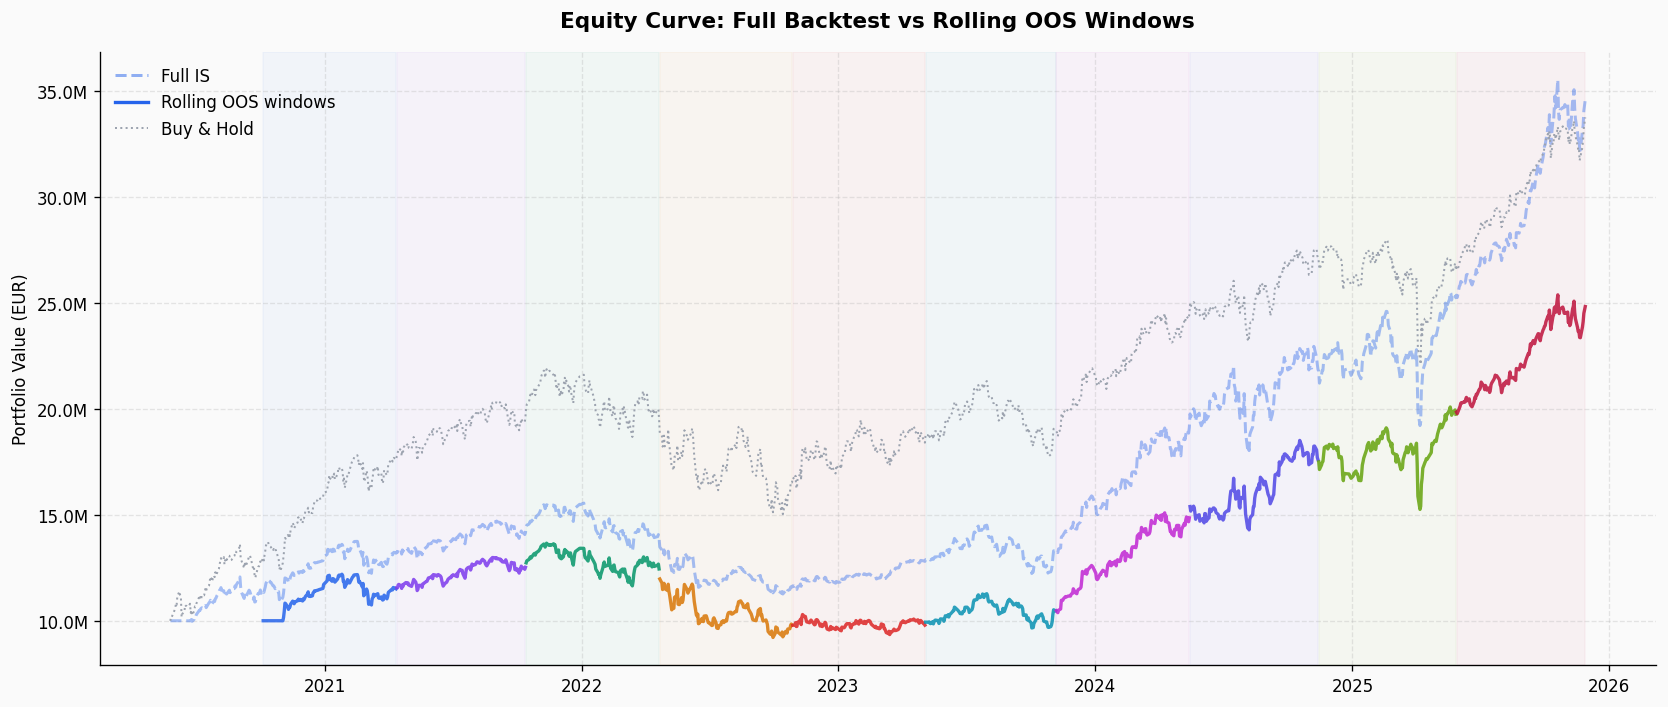

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full backtest
full_vot = full_result.result("merton_mom").combined.value_over_time
ax.plot(full_vot.index, full_vot.values, color=COLORS['primary'],
        linewidth=1.8, label='merton_mom (full IS)', alpha=0.4, linestyle='--')

# Rolling OOS — colored per window
for i, w in enumerate(rolling_strat.windows):
    vot = w.value_over_time
    color = WINDOW_COLORS[i % len(WINDOW_COLORS)]
    label = f'W{i}' if i == 0 else None
    ax.plot(vot.index, vot.values, color=color, linewidth=2.0, alpha=0.85)
    # Shade window background
    ax.axvspan(vot.index[0], vot.index[-1], alpha=0.04, color=color)

# Buy & Hold
bnh_vot = full_result.result("buy_and_hold").combined.value_over_time
ax.plot(bnh_vot.index, bnh_vot.values, color=COLORS['muted'],
        linewidth=1.2, label='Buy & Hold', linestyle=':')

ax.set_title('Equity Curve: Full Backtest vs Rolling OOS Windows', pad=15)
ax.set_ylabel('Portfolio Value (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Custom legend
legend_elements = [
    Line2D([0], [0], color=COLORS['primary'], linewidth=1.8, linestyle='--', alpha=0.5, label='Full IS'),
    Line2D([0], [0], color=WINDOW_COLORS[0], linewidth=2, label='Rolling OOS windows'),
    Line2D([0], [0], color=COLORS['muted'], linewidth=1.2, linestyle=':', label='Buy & Hold'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 — Per-Window Sharpe Ratio

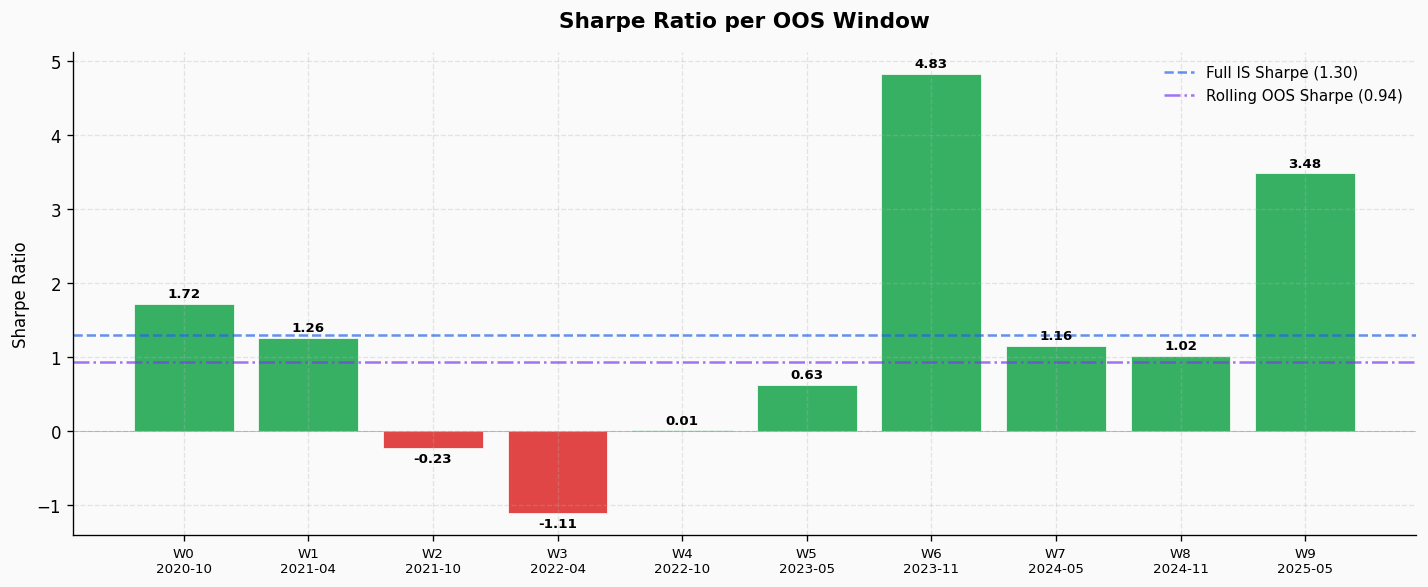

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

sharpes = windows_df['Sharpe'].values
labels = [f"W{i}\n{windows_df.iloc[i]['Start'][:7]}" for i in range(len(windows_df))]
colors = [COLORS['success'] if s > 0 else COLORS['danger'] for s in sharpes]

bars = ax.bar(range(len(sharpes)), sharpes, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

# Reference lines
ax.axhline(is_sharpe, color=COLORS['primary'], linewidth=1.5, linestyle='--',
           label=f'Full IS Sharpe ({is_sharpe:.2f})', alpha=0.7)
ax.axhline(oos_sharpe, color=COLORS['secondary'], linewidth=1.5, linestyle='-.',
           label=f'Rolling OOS Sharpe ({oos_sharpe:.2f})', alpha=0.7)
ax.axhline(0, color=COLORS['dark'], linewidth=0.5, alpha=0.3)

# Value labels on bars
for bar, val in zip(bars, sharpes):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.05 * np.sign(y),
            f'{val:.2f}', ha='center', va='bottom' if y >= 0 else 'top',
            fontsize=8, fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Sharpe Ratio per OOS Window', pad=15)
ax.set_ylabel('Sharpe Ratio')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### 7.3 — Per-Window Returns & Drawdowns

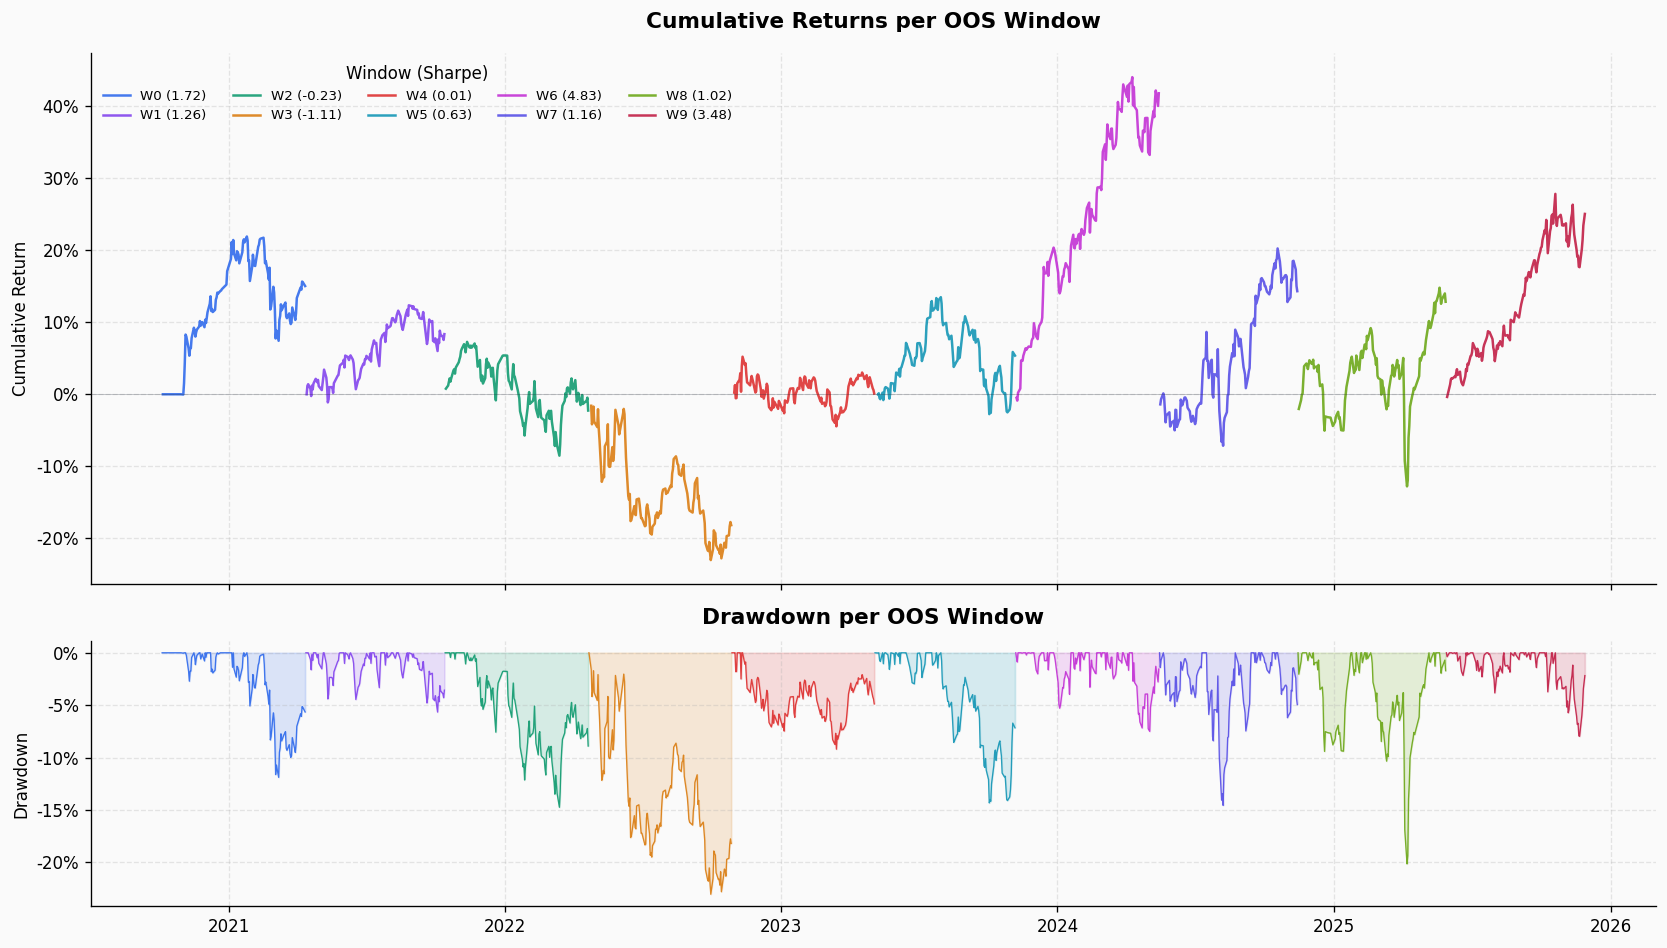

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Cumulative returns per window
ax_ret = axes[0]
for i, w in enumerate(rolling_strat.windows):
    cum_ret = (1 + w.returns_over_time).cumprod() - 1
    color = WINDOW_COLORS[i % len(WINDOW_COLORS)]
    ax_ret.plot(cum_ret.index, cum_ret.values, color=color, linewidth=1.5,
                label=f'W{i} ({w.metrics["sharpe_ratio"]:.2f})', alpha=0.85)

ax_ret.axhline(0, color=COLORS['dark'], linewidth=0.5, alpha=0.3)
ax_ret.set_title('Cumulative Returns per OOS Window', pad=15)
ax_ret.set_ylabel('Cumulative Return')
ax_ret.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax_ret.legend(title='Window (Sharpe)', fontsize=8, frameon=False,
              ncol=min(5, rolling_strat.n_windows), loc='upper left')

# Drawdown per window
ax_dd = axes[1]
for i, w in enumerate(rolling_strat.windows):
    dd = w.drawdown
    color = WINDOW_COLORS[i % len(WINDOW_COLORS)]
    ax_dd.fill_between(dd.index, dd.values, 0, color=color, alpha=0.15)
    ax_dd.plot(dd.index, dd.values, color=color, linewidth=0.8, alpha=0.85)

ax_dd.set_title('Drawdown per OOS Window', pad=10)
ax_dd.set_ylabel('Drawdown')
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

### 7.4 — Rolling Sharpe: Full IS vs Rolling OOS

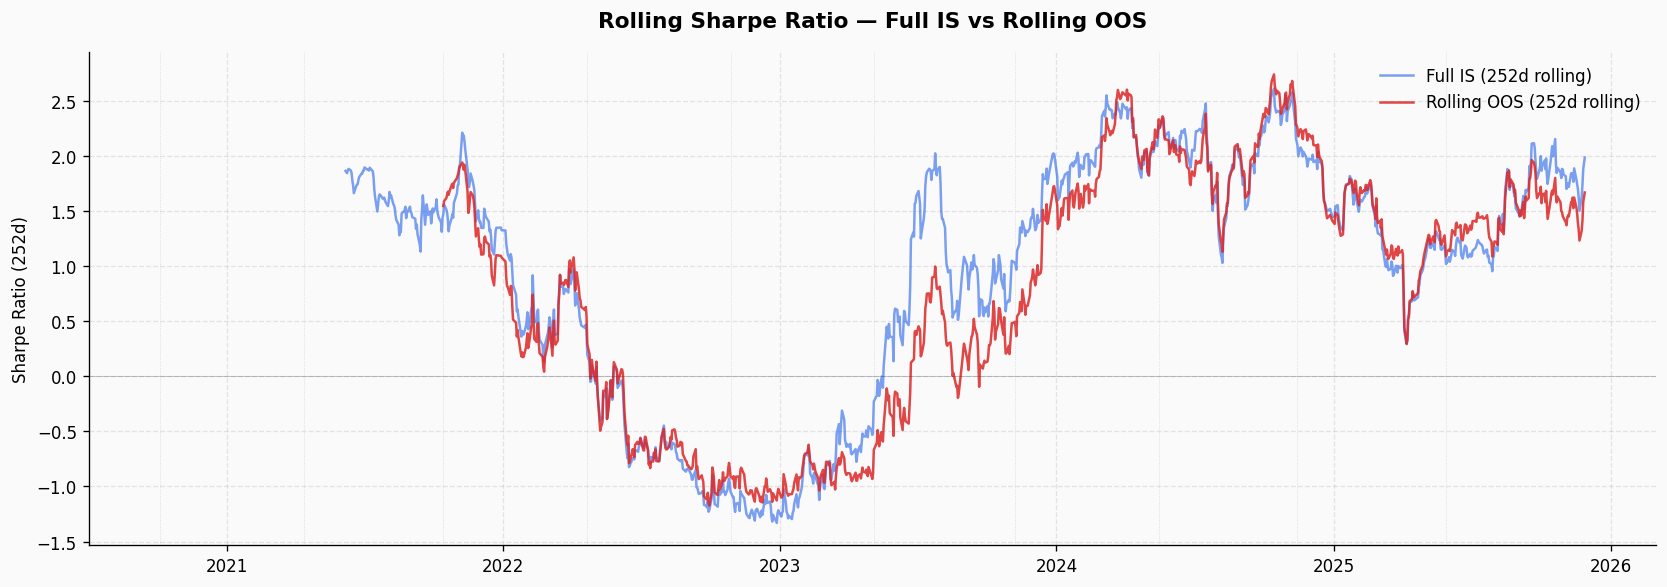

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

# Full backtest rolling sharpe
full_ret = full_result.result("merton_mom").combined.returns_over_time
rs_full = (full_ret.rolling(252).mean() / full_ret.rolling(252).std()) * np.sqrt(252)
ax.plot(rs_full.index, rs_full.values, color=COLORS['primary'],
        linewidth=1.5, label='Full IS (252d rolling)', alpha=0.6)

# Rolling OOS rolling sharpe
rolling_ret = rolling_strat.combined.returns_over_time
rs_rolling = (rolling_ret.rolling(252).mean() / rolling_ret.rolling(252).std()) * np.sqrt(252)
ax.plot(rs_rolling.index, rs_rolling.values, color=COLORS['danger'],
        linewidth=1.5, label='Rolling OOS (252d rolling)', alpha=0.85)

# Window boundaries
for i, w in enumerate(rolling_strat.windows):
    ax.axvline(w.dates[0], color=COLORS['muted'], linewidth=0.5, alpha=0.4, linestyle=':')

ax.axhline(0, color=COLORS['dark'], linewidth=0.5, alpha=0.3)
ax.set_title('Rolling Sharpe Ratio — Full IS vs Rolling OOS', pad=15)
ax.set_ylabel('Sharpe Ratio (252d)')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

### 7.5 — IS vs OOS Metric Comparison (Radar-Style Bar Chart)

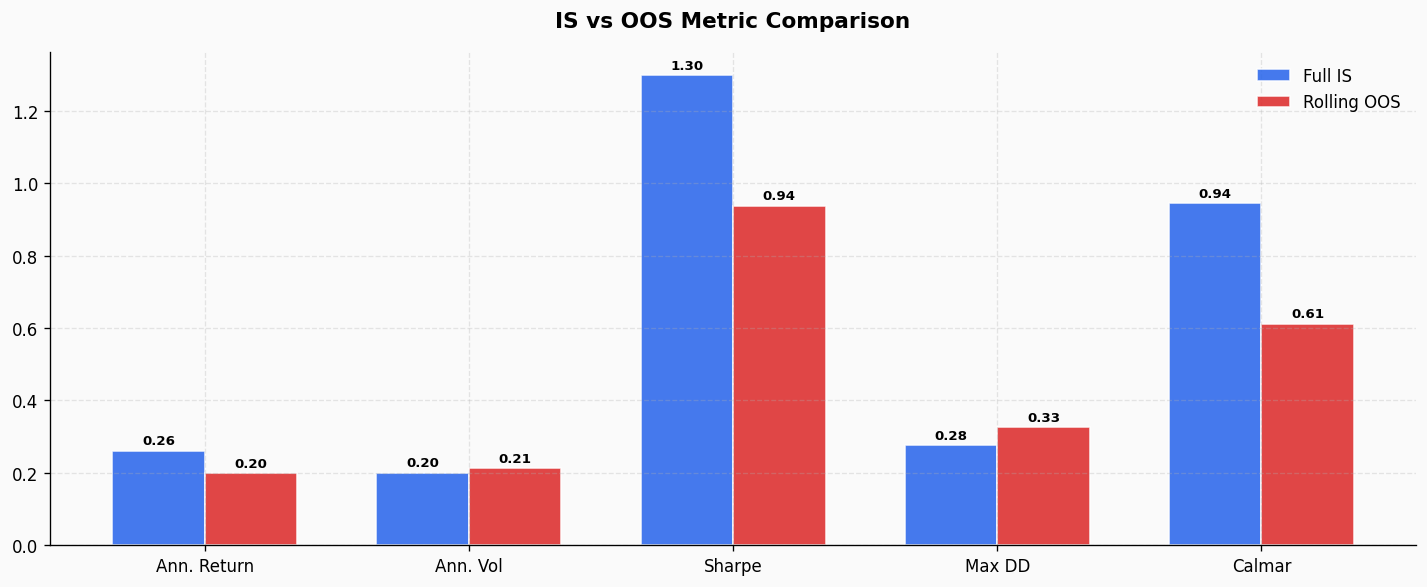

In [14]:
metrics_to_compare = ['annualized_return', 'annualized_volatility', 'sharpe_ratio',
                       'max_drawdown', 'calmar_ratio']
labels_nice = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar']

is_vals = [full_m[k] for k in metrics_to_compare]
oos_vals = [rolling_m[k] for k in metrics_to_compare]

# For Max DD, negate for display (make positive = worse)
is_display = [abs(v) if k == 'max_drawdown' else v for v, k in zip(is_vals, metrics_to_compare)]
oos_display = [abs(v) if k == 'max_drawdown' else v for v, k in zip(oos_vals, metrics_to_compare)]

x = np.arange(len(labels_nice))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, is_display, width, label='Full IS',
               color=COLORS['primary'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, oos_display, width, label='Rolling OOS',
               color=COLORS['danger'], alpha=0.85, edgecolor='white')

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_nice, fontsize=10)
ax.set_title('IS vs OOS Metric Comparison', pad=15)
ax.legend(frameon=False, fontsize=10)
ax.axhline(0, color=COLORS['dark'], linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.6 — Walk-Forward: Train vs Test Sharpe per Window

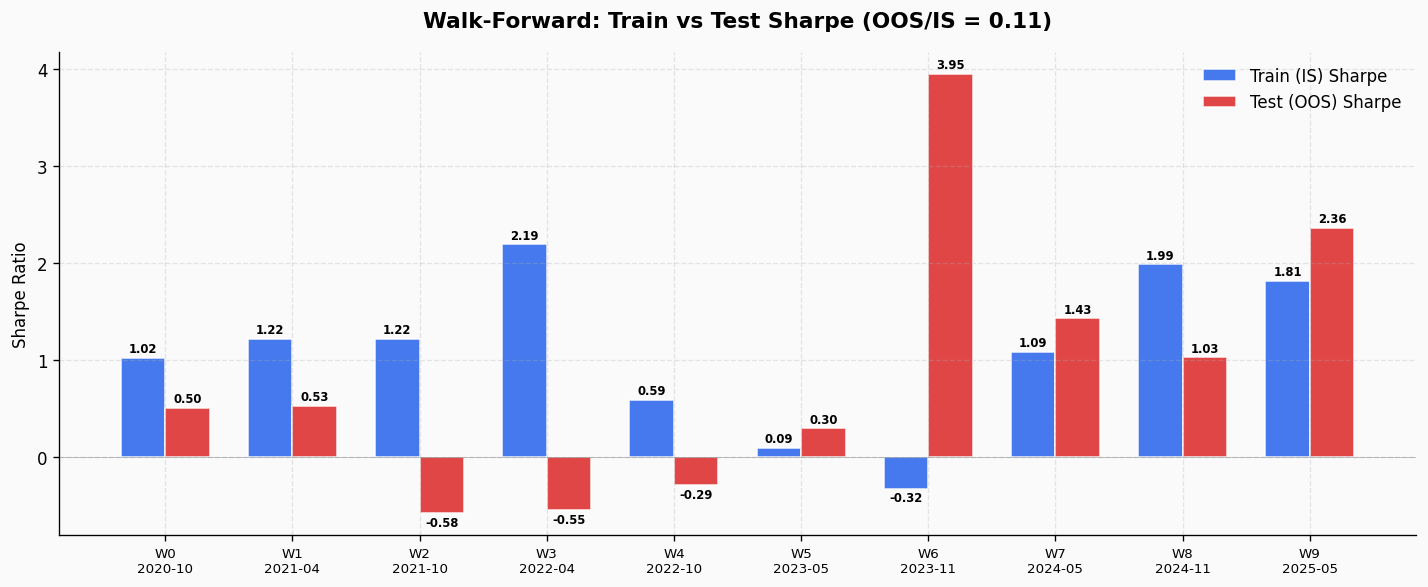

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

wf_df = wf_result.summary()
n_windows = len(wf_df)
x = np.arange(n_windows)
width = 0.35

bars_train = ax.bar(x - width/2, wf_df['train_metric'], width,
                     label='Train (IS) Sharpe', color=COLORS['primary'], alpha=0.85, edgecolor='white')
bars_test = ax.bar(x + width/2, wf_df['test_sharpe'], width,
                    label='Test (OOS) Sharpe', color=COLORS['danger'], alpha=0.85, edgecolor='white')

# Value labels
for bars in [bars_train, bars_test]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.03 * np.sign(h),
                    f'{h:.2f}', ha='center', va='bottom' if h >= 0 else 'top',
                    fontsize=7, fontweight='bold')

ax.axhline(0, color=COLORS['dark'], linewidth=0.5, alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels([f"W{i}\n{wf_df.iloc[i]['test_start'].strftime('%Y-%m')}" for i in range(n_windows)], fontsize=8)
ax.set_title(f'Walk-Forward: Train vs Test Sharpe (OOS/IS = {wf_result.oos_is_ratio:.2f})', pad=15)
ax.set_ylabel('Sharpe Ratio')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

### 7.7 — Parameter Stability Across WF Windows

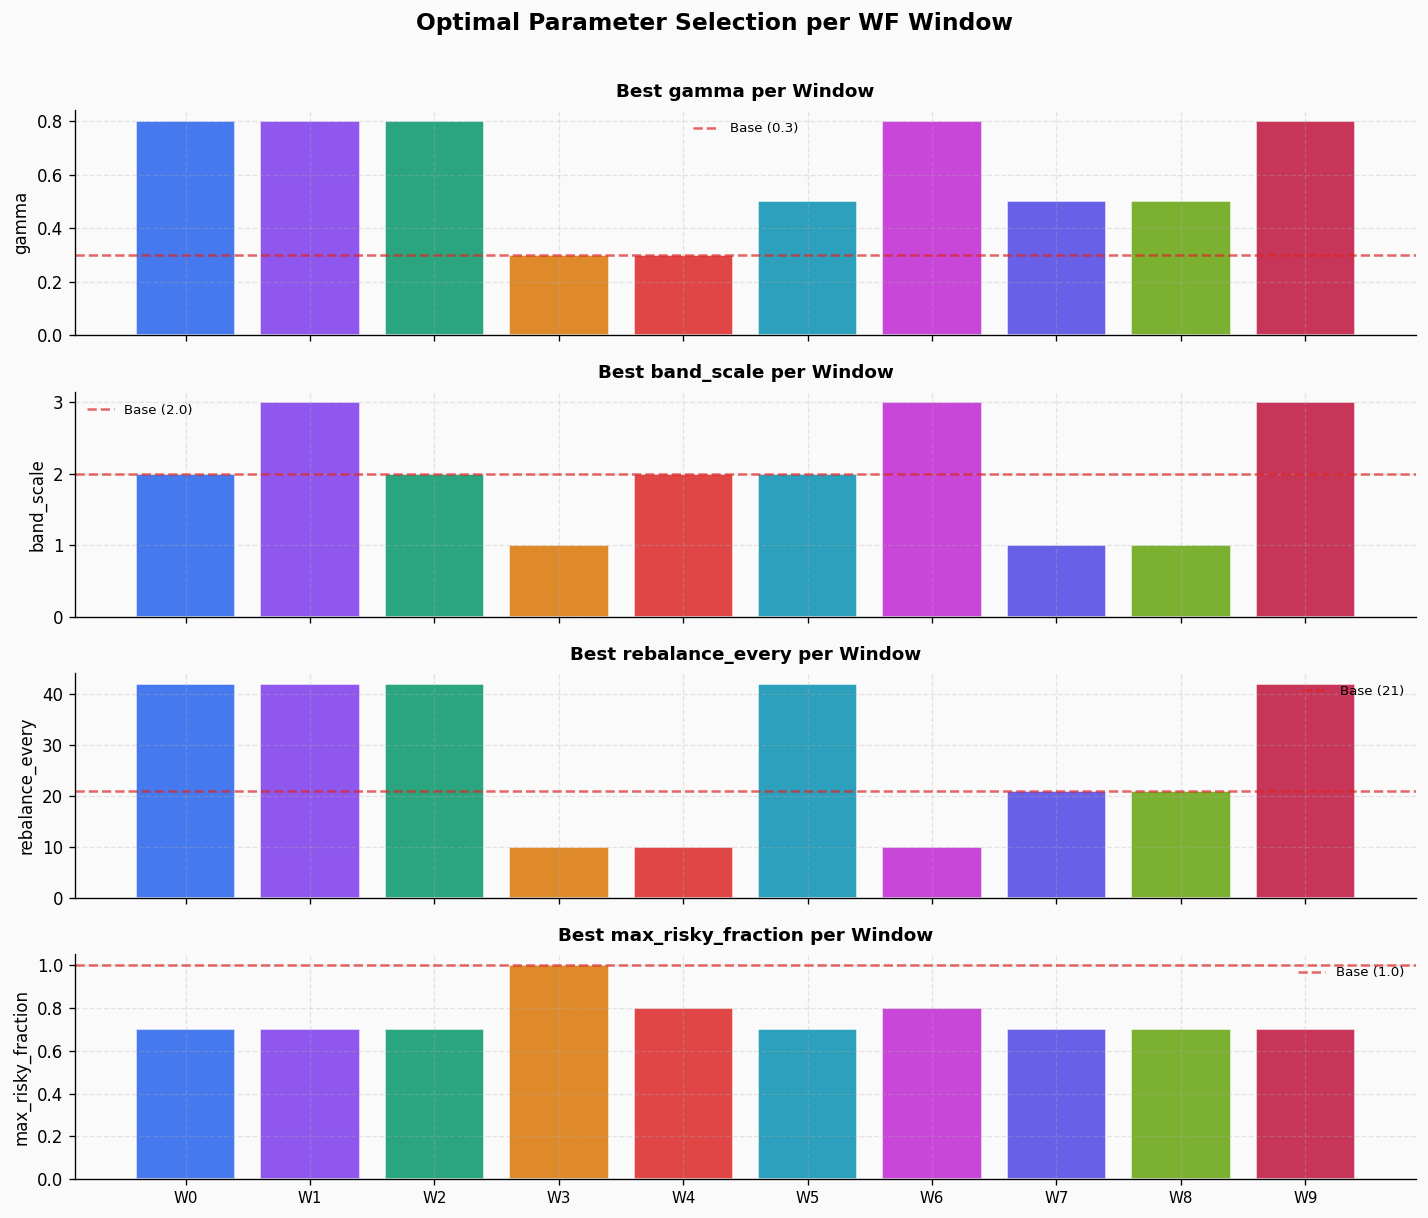

In [16]:
param_cols = [c for c in wf_df.columns if c.startswith('param_')]

if len(param_cols) > 0:
    n_params = len(param_cols)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for ax, col in zip(axes, param_cols):
        name = col.replace('param_', '')
        vals = wf_df[col].values
        colors = [WINDOW_COLORS[i % len(WINDOW_COLORS)] for i in range(len(vals))]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='white')
        ax.set_ylabel(name, fontsize=10)
        ax.set_title(f'Best {name} per Window', fontsize=11, fontweight='bold', pad=8)

        # Annotate with base param value if applicable
        if name in BASE_PARAMS:
            base_val = BASE_PARAMS[name]
            ax.axhline(base_val, color=COLORS['danger'], linewidth=1.5, linestyle='--',
                       alpha=0.7, label=f'Base ({base_val})')
            ax.legend(frameon=False, fontsize=8)

    axes[-1].set_xticks(range(len(wf_df)))
    axes[-1].set_xticklabels([f"W{i}" for i in range(len(wf_df))], fontsize=9)

    fig.suptitle('Optimal Parameter Selection per WF Window', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No parameter columns found in WF summary.")

### 7.8 — Monthly Returns Heatmap (Rolling OOS)

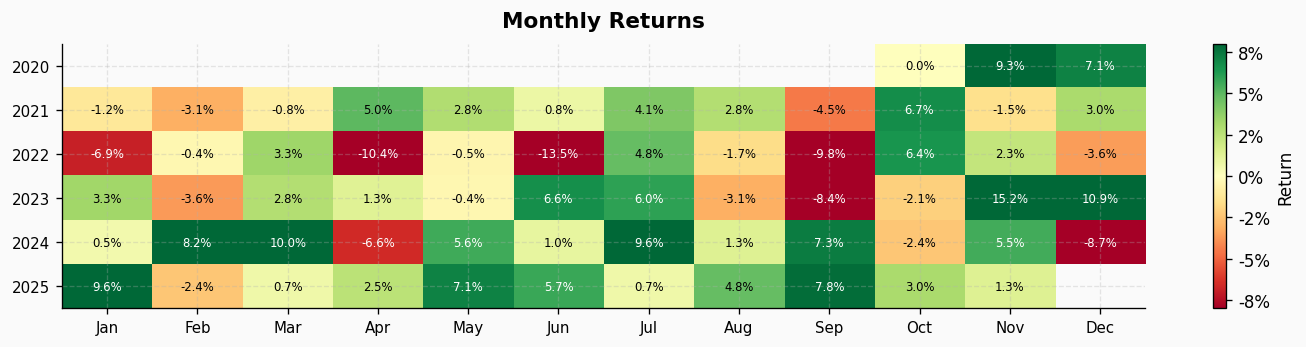

In [17]:
rolling_strat.plot_monthly_heatmap()

### 7.9 — Drawdown Comparison: Full IS vs Rolling OOS

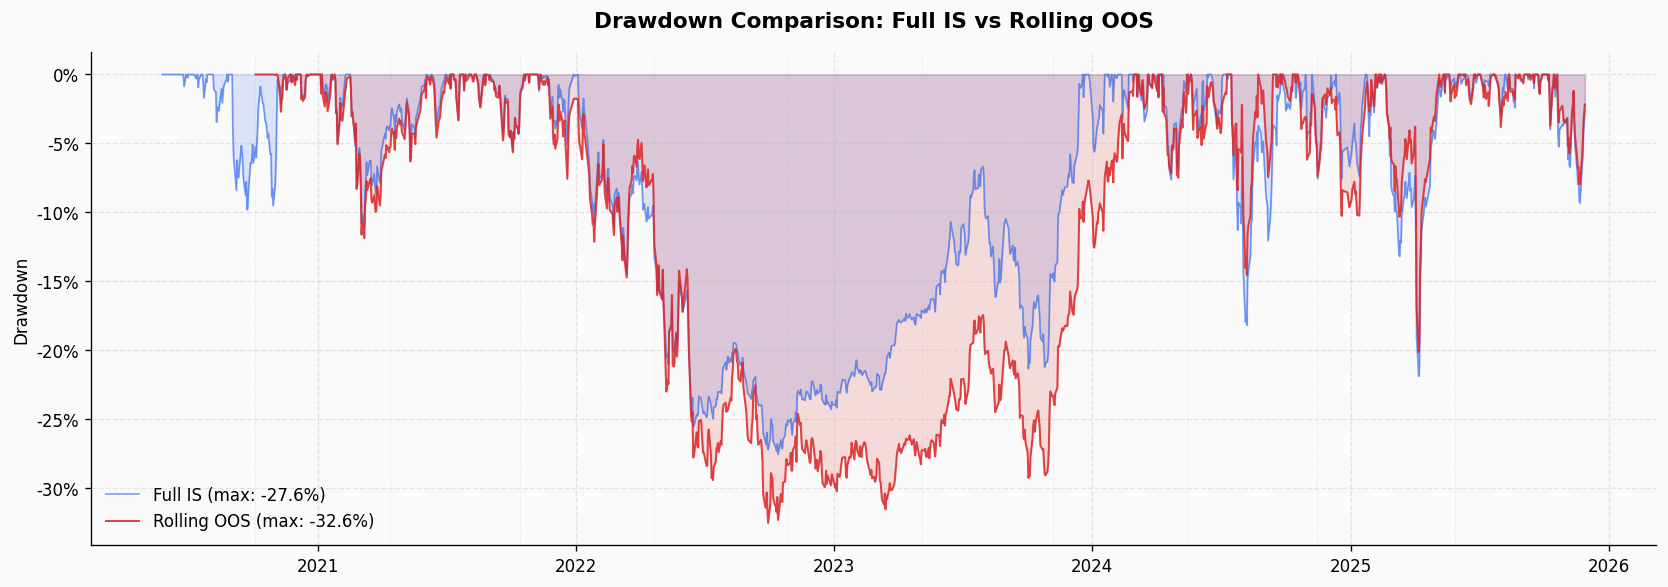

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

dd_full = full_result.result("merton_mom").combined.drawdown
dd_rolling = rolling_strat.combined.drawdown

ax.fill_between(dd_full.index, dd_full.values, 0, color=COLORS['primary'], alpha=0.15)
ax.plot(dd_full.index, dd_full.values, color=COLORS['primary'],
        linewidth=1, alpha=0.6, label=f'Full IS (max: {dd_full.min():.1%})')

ax.fill_between(dd_rolling.index, dd_rolling.values, 0, color=COLORS['danger'], alpha=0.15)
ax.plot(dd_rolling.index, dd_rolling.values, color=COLORS['danger'],
        linewidth=1.2, alpha=0.85, label=f'Rolling OOS (max: {dd_rolling.min():.1%})')

# Window boundaries
for w in rolling_strat.windows:
    ax.axvline(w.dates[0], color=COLORS['muted'], linewidth=0.5, alpha=0.3, linestyle=':')

ax.set_title('Drawdown Comparison: Full IS vs Rolling OOS', pad=15)
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

### 7.10 — Rolling Volatility: Full IS vs Rolling OOS

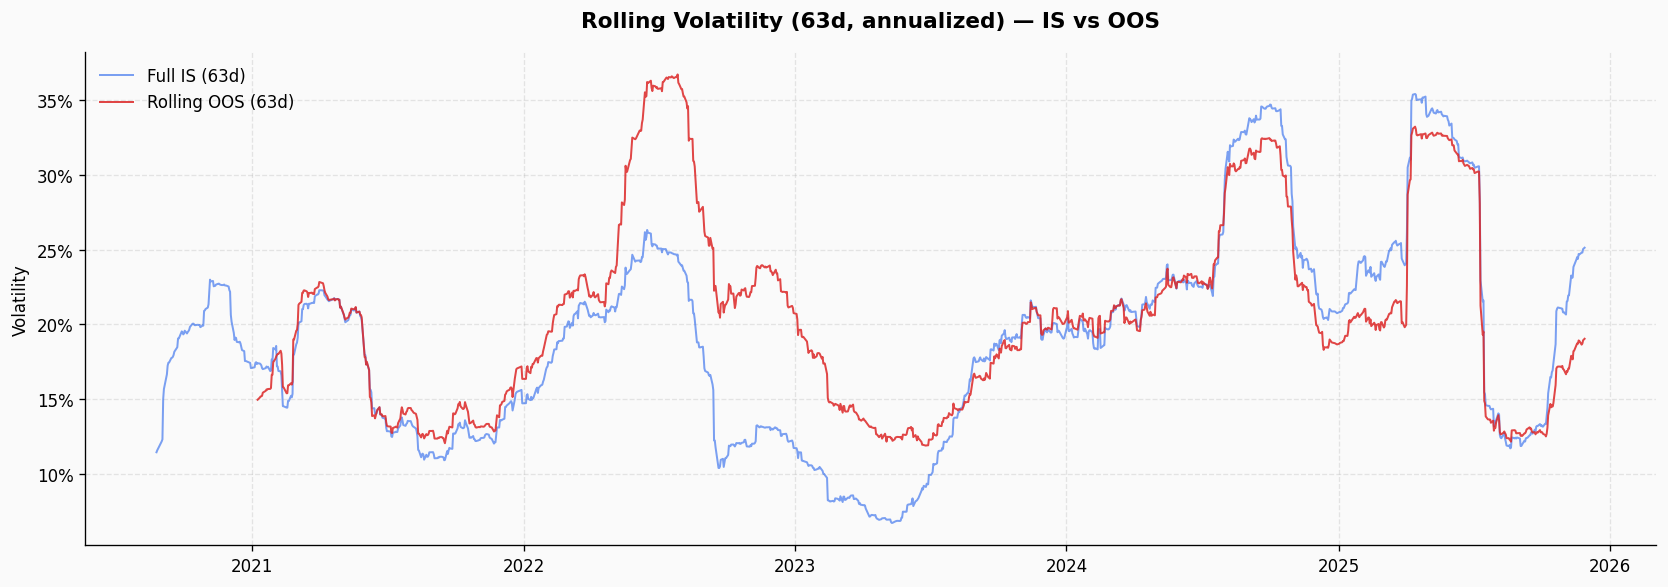

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

vol_full = full_ret.rolling(63).std() * np.sqrt(252)
vol_rolling = rolling_ret.rolling(63).std() * np.sqrt(252)

ax.plot(vol_full.index, vol_full.values, color=COLORS['primary'],
        linewidth=1.2, alpha=0.6, label='Full IS (63d)')
ax.plot(vol_rolling.index, vol_rolling.values, color=COLORS['danger'],
        linewidth=1.2, alpha=0.85, label='Rolling OOS (63d)')

ax.set_title('Rolling Volatility (63d, annualized) — IS vs OOS', pad=15)
ax.set_ylabel('Volatility')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## 8. Comprehensive Summary Table

In [20]:
# Build comprehensive comparison table
bnh_m = full_result.result("buy_and_hold").metrics
wf_m = wf_result.combined_metrics

summary_table = pd.DataFrame({
    'Full IS (merton_mom)': full_m,
    'Rolling OOS (fixed params)': rolling_m,
    'WF Optimized (OOS)': wf_m,
    'Buy & Hold': bnh_m,
}).T

cols = ['total_return', 'annualized_return', 'annualized_volatility',
        'sharpe_ratio', 'max_drawdown', 'calmar_ratio']
col_labels = ['Total Return', 'Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar']

display_df = summary_table[cols].copy()
display_df.columns = col_labels

print("=" * 80)
print("COMPREHENSIVE COMPARISON")
print("=" * 80)
display(display_df.style.format({
    'Total Return': '{:.2%}', 'Ann. Return': '{:.2%}', 'Ann. Vol': '{:.2%}',
    'Sharpe': '{:.4f}', 'Max DD': '{:.2%}', 'Calmar': '{:.4f}',
}).background_gradient(subset=['Sharpe'], cmap='RdYlGn', vmin=0, vmax=2)
 .background_gradient(subset=['Max DD'], cmap='RdYlGn', vmin=-0.5, vmax=0))

print(f"\n--- Robustness Ratios ---")
print(f"Rolling OOS/IS Sharpe:     {oos_is_ratio:.4f}")
print(f"WF Optimized OOS/IS:       {wf_result.oos_is_ratio:.4f}")
print(f"\n--- Window Statistics ---")
print(f"Windows with Sharpe > 0:   {(windows_df['Sharpe'] > 0).sum()}/{len(windows_df)}")
print(f"Windows with Sharpe > 0.5: {(windows_df['Sharpe'] > 0.5).sum()}/{len(windows_df)}")
print(f"Mean window Sharpe:        {windows_df['Sharpe'].mean():.4f}")
print(f"Std window Sharpe:         {windows_df['Sharpe'].std():.4f}")
print(f"Min/Max window Sharpe:     {windows_df['Sharpe'].min():.4f} / {windows_df['Sharpe'].max():.4f}")
print(f"Mean window Max DD:        {windows_df['Max DD'].mean():.2%}")

COMPREHENSIVE COMPARISON


,Total Return,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar
Full IS (merton_mom),245.67%,26.05%,20.08%,1.2973,-27.58%,0.9447
Rolling OOS (fixed params),148.15%,19.93%,21.28%,0.9370,-32.55%,0.6124
WF Optimized (OOS),11.73%,2.24%,19.48%,0.1151,-30.64%,0.0732
Buy & Hold,237.52%,25.49%,22.21%,1.1478,-31.26%,0.8154



--- Robustness Ratios ---
Rolling OOS/IS Sharpe:     0.7222
WF Optimized OOS/IS:       0.1056

--- Window Statistics ---
Windows with Sharpe > 0:   8/10
Windows with Sharpe > 0.5: 7/10
Mean window Sharpe:        1.2772
Std window Sharpe:         1.7553
Min/Max window Sharpe:     -1.1073 / 4.8280
Mean window Max DD:        -12.90%


## 9. Sensitivity: Sharpe Heatmaps

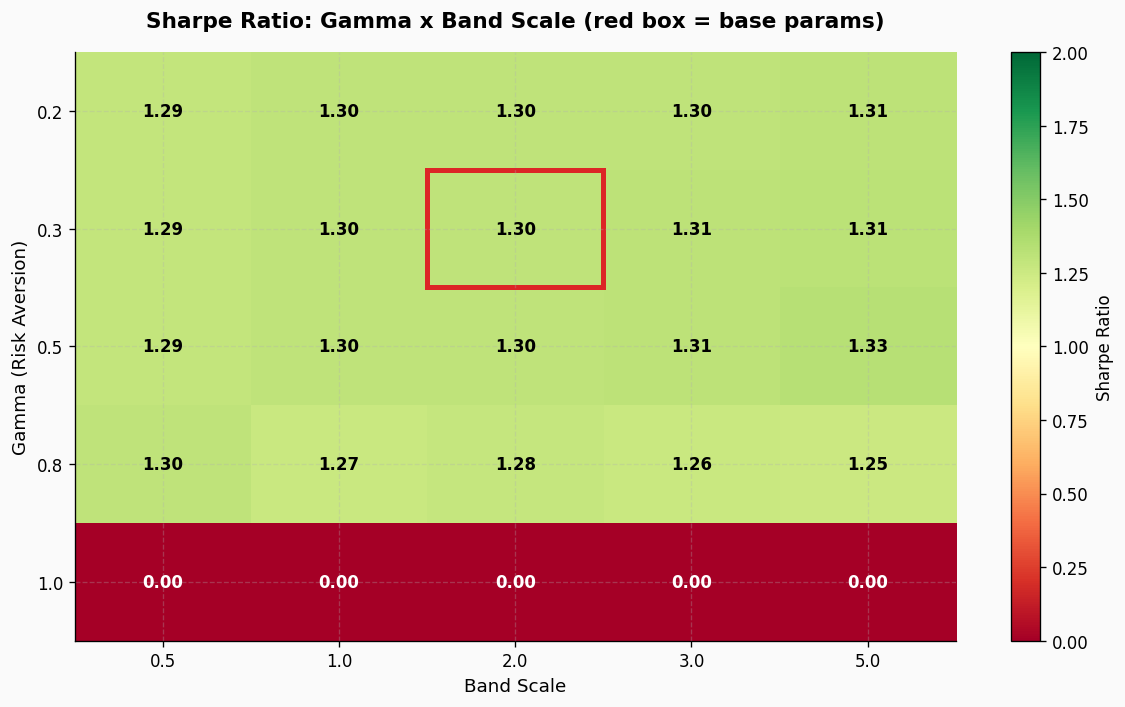

In [21]:
# Run sensitivity analysis — vary gamma and band_scale with other params fixed
from src.backtesting import Backtest

gammas = [0.2, 0.3, 0.5, 0.8, 1.0]
band_scales = [0.5, 1.0, 2.0, 3.0, 5.0]
rebalance_freqs = [10, 21, 42]

# Gamma x Band Scale heatmap
sharpe_matrix = np.zeros((len(gammas), len(band_scales)))

for i, g in enumerate(gammas):
    for j, bs in enumerate(band_scales):
        strat = make_merton_mom(
            name=f'g{g}_bs{bs}',
            gamma=g, band_scale=bs,
        )
        r = Backtest(
            portfolio=make_portfolio(),
            universe=universe,
            strategies=[strat],
            history=history,
            broker=Broker(universe.transaction_costs),
            warmup_size=504,
        ).run()
        sharpe_matrix[i, j] = r.result(strat.name).metrics['sharpe_ratio']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sharpe_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=2)
ax.set_xticks(range(len(band_scales)))
ax.set_xticklabels(band_scales, fontsize=10)
ax.set_yticks(range(len(gammas)))
ax.set_yticklabels(gammas, fontsize=10)
ax.set_xlabel('Band Scale', fontsize=11)
ax.set_ylabel('Gamma (Risk Aversion)', fontsize=11)

for i in range(len(gammas)):
    for j in range(len(band_scales)):
        val = sharpe_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > 1.5 or val < 0.5 else 'black')

# Mark base params
base_i = gammas.index(BASE_PARAMS['gamma'])
base_j = band_scales.index(BASE_PARAMS['band_scale'])
rect = Rectangle((base_j - 0.5, base_i - 0.5), 1, 1,
                  linewidth=3, edgecolor=COLORS['danger'], facecolor='none')
ax.add_patch(rect)

plt.colorbar(im, ax=ax, label='Sharpe Ratio')
ax.set_title('Sharpe Ratio: Gamma x Band Scale (red box = base params)', pad=15)
plt.tight_layout()
plt.show()

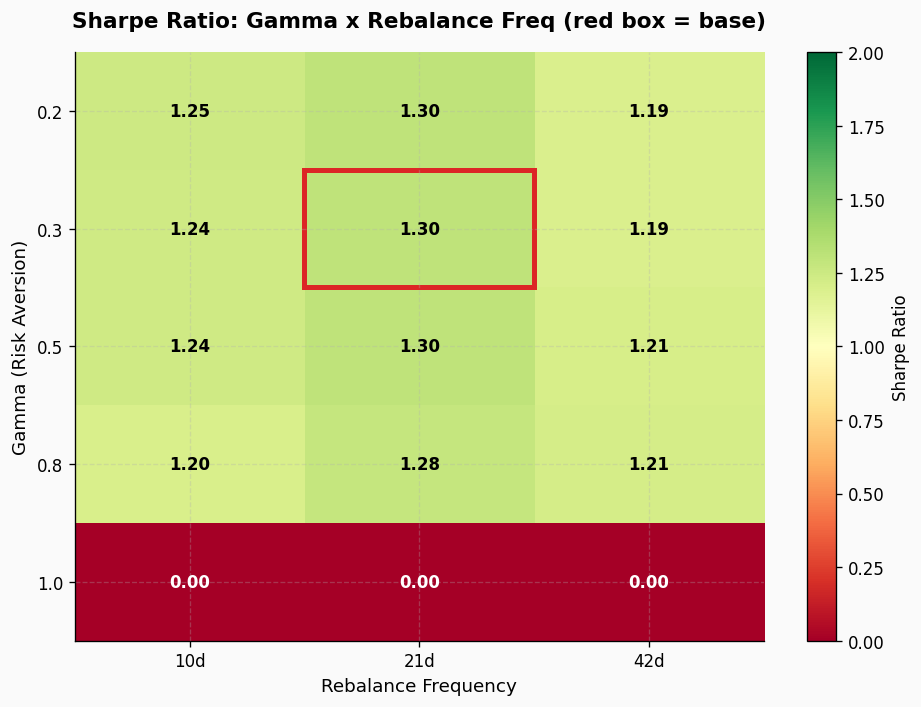

In [22]:
# Gamma x Rebalance Frequency heatmap
sharpe_matrix_2 = np.zeros((len(gammas), len(rebalance_freqs)))

for i, g in enumerate(gammas):
    for j, rb in enumerate(rebalance_freqs):
        strat = make_merton_mom(
            name=f'g{g}_rb{rb}',
            gamma=g, rebalance_every=rb,
        )
        r = Backtest(
            portfolio=make_portfolio(),
            universe=universe,
            strategies=[strat],
            history=history,
            broker=Broker(universe.transaction_costs),
            warmup_size=504,
        ).run()
        sharpe_matrix_2[i, j] = r.result(strat.name).metrics['sharpe_ratio']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sharpe_matrix_2, cmap='RdYlGn', aspect='auto', vmin=0, vmax=2)
ax.set_xticks(range(len(rebalance_freqs)))
ax.set_xticklabels([f'{r}d' for r in rebalance_freqs], fontsize=10)
ax.set_yticks(range(len(gammas)))
ax.set_yticklabels(gammas, fontsize=10)
ax.set_xlabel('Rebalance Frequency', fontsize=11)
ax.set_ylabel('Gamma (Risk Aversion)', fontsize=11)

for i in range(len(gammas)):
    for j in range(len(rebalance_freqs)):
        val = sharpe_matrix_2[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > 1.5 or val < 0.5 else 'black')

# Mark base params
base_i = gammas.index(BASE_PARAMS['gamma'])
base_j = rebalance_freqs.index(BASE_PARAMS['rebalance_every'])
rect = Rectangle((base_j - 0.5, base_i - 0.5), 1, 1,
                  linewidth=3, edgecolor=COLORS['danger'], facecolor='none')
ax.add_patch(rect)

plt.colorbar(im, ax=ax, label='Sharpe Ratio')
ax.set_title('Sharpe Ratio: Gamma x Rebalance Freq (red box = base)', pad=15)
plt.tight_layout()
plt.show()

## 10. Cost Impact Analysis

In [23]:
# Test robustness to higher costs (2x stress test)
double_costs = {k: v * 2 for k, v in universe.transaction_costs.items()}

strat_normal = make_merton_mom(name='normal_costs')
strat_double = make_merton_mom(name='double_costs')

r_normal = Backtest(
    portfolio=make_portfolio(), universe=universe,
    strategies=[strat_normal], history=history,
    broker=Broker(universe.transaction_costs), warmup_size=504,
).run()

r_double = Backtest(
    portfolio=make_portfolio(), universe=universe,
    strategies=[strat_double], history=history,
    broker=Broker(double_costs), warmup_size=504,
).run()

m_normal = r_normal.result('normal_costs').metrics
m_double = r_double.result('double_costs').metrics

cost_comparison = pd.DataFrame({
    'Normal Costs': m_normal,
    '2x Costs (Stress)': m_double,
}).T[cols]
cost_comparison.columns = col_labels

print("=" * 60)
print("COST STRESS TEST")
print("=" * 60)
display(cost_comparison.style.format({
    'Total Return': '{:.2%}', 'Ann. Return': '{:.2%}', 'Ann. Vol': '{:.2%}',
    'Sharpe': '{:.4f}', 'Max DD': '{:.2%}', 'Calmar': '{:.4f}',
}))

sharpe_degradation = (m_double['sharpe_ratio'] - m_normal['sharpe_ratio']) / m_normal['sharpe_ratio']
print(f"\nSharpe degradation with 2x costs: {sharpe_degradation:.1%}")
print(f"Normal costs: ${r_normal.result('normal_costs').combined.total_costs:,.0f}")
print(f"Double costs:  ${r_double.result('double_costs').combined.total_costs:,.0f}")

COST STRESS TEST


,Total Return,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar
Normal Costs,245.67%,26.05%,20.08%,1.2973,-27.58%,0.9447
2x Costs (Stress),243.91%,25.93%,20.08%,1.2911,-27.64%,0.9382



Sharpe degradation with 2x costs: -0.5%
Normal costs: $78,430
Double costs:  $156,391


## 11. Conclusions

In [24]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              WALK-FORWARD VALIDATION — CONCLUSIONS             ║
╚══════════════════════════════════════════════════════════════════╝

1. ROBUSTNESS METRICS
""")

print(f"   OOS/IS Sharpe (fixed params): {oos_is_ratio:.4f}")
print(f"   OOS/IS Sharpe (WF optimized): {wf_result.oos_is_ratio:.4f}")
print(f"   Positive-Sharpe windows:      {(windows_df['Sharpe'] > 0).sum()}/{len(windows_df)}")
print(f"   Sharpe std across windows:    {windows_df['Sharpe'].std():.4f}")

print(f"""
2. INTERPRETATION
   - OOS/IS >= 0.6 → robust
   - OOS/IS 0.3-0.6 → moderate overfitting
   - OOS/IS < 0.3 → significant overfitting

3. COMPARISON vs MertonFull OPTIMIZER
   - MertonFull WF OOS/IS was 0.14 (catastrophic)
   - merton_mom OOS/IS (fixed params) = {oos_is_ratio:.4f}
   - This {'confirms' if oos_is_ratio > 0.3 else 'does NOT confirm'} that fixed, theory-based params
     are {'more' if oos_is_ratio > 0.14 else 'NOT more'} robust than grid-search optimized ones.

4. RECOMMENDATION
   {'✓ merton_mom with base params is viable for live trading' if oos_is_ratio > 0.4 else '⚠ Consider parameter adjustments before live trading'}
""")


╔══════════════════════════════════════════════════════════════════╗
║              WALK-FORWARD VALIDATION — CONCLUSIONS             ║
╚══════════════════════════════════════════════════════════════════╝

1. ROBUSTNESS METRICS

   OOS/IS Sharpe (fixed params): 0.7222
   OOS/IS Sharpe (WF optimized): 0.1056
   Positive-Sharpe windows:      8/10
   Sharpe std across windows:    1.7553

2. INTERPRETATION
   - OOS/IS >= 0.6 → robust
   - OOS/IS 0.3-0.6 → moderate overfitting
   - OOS/IS < 0.3 → significant overfitting

3. COMPARISON vs MertonFull OPTIMIZER
   - MertonFull WF OOS/IS was 0.14 (catastrophic)
   - merton_mom OOS/IS (fixed params) = 0.7222
   - This confirms that fixed, theory-based params
     are more robust than grid-search optimized ones.

4. RECOMMENDATION
   ✓ merton_mom with base params is viable for live trading

